# Models evaluation - Test 1 (Synthetic Copy)

Hello! This notebook documents the code that was written to evalutate the models on different capabilities. We also include results of the evaluations. 

Here we will be testing the models on the synthetic copy test - the models are tasked with processing a text composed of N true and M noise tokens (the noise tokens are uniform), and then with outputting the N true tokens.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import random

# Build vocab for all models & tests. 
# We employ the same vocab size to be fair 

vocab = dict()

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ{.}()[]|"

for i in range(10):
    vocab[str(i)] = i

for char in characters:
    vocab[char] = len(vocab)

for i in range(100):
    vocab[f"NOISE_{i}"] = len(vocab)

vocab["<ENDSEQ>"] = len(vocab)
vocab["<STABLENOISE>"] = len(vocab)
vocab["<STARTTASK>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

In [8]:
def get_batch_ex3(batch_size, vocab, copy_size=5, buffer_size=50, device="cuda"):

    first_noise_ix = vocab["NOISE_0"]
    last_noise_ix = vocab["NOISE_99"]

    # Random noise
    noise_tensor = torch.randint(first_noise_ix, last_noise_ix + 1, (batch_size, buffer_size), device=device )

    # Random digits
    copy_tensor = torch.randint(0, 10, (batch_size, copy_size), device=device)

    # Choose positions for the digits.
    # Each row gets its own random positions.
    positions = (torch.rand(batch_size, buffer_size, device=device).argsort(dim=-1)[..., :copy_size].sort(dim=-1).values)

    # Put the digits into the noise
    ready_tensor = noise_tensor.clone()

    ready_tensor.scatter_(dim=-1, index=positions, src=copy_tensor)

    marker_tensor = torch.full(
        (batch_size, 1),
        vocab["<STARTTASK>"],
        device=device,
    )

    ready_tensor = torch.cat([ready_tensor, marker_tensor], dim=-1)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor.sort(dim=-1).values


def diagnose_ex3(model, copy_size, buffer_size, vocab, teacher_forcing=False):

    batch_size=1 #Analyzing one random sample
    batch, targets = get_batch_ex3(batch_size, vocab, copy_size, buffer_size)
    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

    logits, gates = model.predict_inference(
        x=batch,
        vocab=vocab,
        max_len=copy_size-1,
        diagnostic=True
    )

    tokens = torch.argmax(logits, dim=2) # (batch, seq)

    gates = {
        name: np.array(gate)
        for name, gate in gates.items()
    }

    fig, axes = plt.subplots(
        1,
        len(gates),
        figsize=(8 * len(gates), 8)
    )
    
    if len(gates) == 1:
        axes = [axes]
    
    vmin = min(gate.min() for gate in gates.values())
    vmax = max(gate.max() for gate in gates.values())
    
    for ax, (name, gate) in zip(axes, gates.items()):
        im = ax.imshow(
            gate.T,
            cmap="viridis",
            aspect="auto",
            vmin=vmin,
            vmax=vmax
        )
    
        ax.set_title(name)
        ax.set_xlabel("Step")
        ax.set_ylabel("Hidden dimension")
        fig.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()

def diagnose_ex3_scalar_graph(model, copy_size, buffer_size, vocab, teacher_forcing=False):

    batch_size=1 #Analyzing one random sample
    batch, targets = get_batch_ex3(batch_size, vocab, copy_size, buffer_size)
    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

    logits, gates = model.predict_inference(
        x=batch,
        vocab=vocab,
        max_len=copy_size-1,
        diagnostic=True
    )

    tokens = torch.argmax(logits, dim=2) # (batch, seq)

    gates = {
        name: np.array(gate)
        for name, gate in gates.items()
    }

    fig, axes = plt.subplots(
        1,
        len(gates),
        figsize=(6 * len(gates), 5)
    )
    
    if len(gates) == 1:
        axes = [axes]
    
    for ax, (name, gate) in zip(axes, gates.items()):
        ax.plot(gate)
    
        ax.set_title(name)
        ax.set_xlabel("Step")
        ax.set_ylabel("Gate value")
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [3]:
import custom_models

hid=256
m_hid = 16
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []

device = "cuda"

sLSTM_model = custom_models.sLSTM(hid, emb, device="cuda")
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)

MGU_model = custom_models.MRRN(hid, emb, device="cuda")
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)

GRU_model = custom_models.CopyGRU(hid, emb, device="cuda")
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)

maGRU_model = custom_models.maGRU(hid, emb, device="cuda")
opt_maGRU = torch.optim.Adam(maGRU_model.parameters(), lr=lr)

eGRU_model = custom_models.eGRU(hid, emb, device="cuda")
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

mLSTM_model = custom_models.mLSTM(m_hid, emb, device=device)
opt_mLSTM = torch.optim.Adam(mLSTM_model.parameters(), lr=lr)

mLSTMLite_model = custom_models.mLSTMLite(m_hid, emb, device=device)
opt_mLSTMLite = torch.optim.Adam(mLSTMLite_model.parameters(), lr=lr)

## Testing the models!

In [4]:
def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [5]:
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

load_model("./models/ex2/mLSTM_100_ex2_epoch_7000.pt", "cuda", mLSTM_model, opt_mLSTM)
load_model("./models/ex2/mLSTMLite_100_ex2_epoch_7000.pt", "cuda", mLSTMLite_model, opt_mLSTMLite)
load_model("./models/ex2/sLSTM_100_ex2_epoch_7000.pt", "cuda", sLSTM_model, opt_sLSTM)
load_model("./models/ex2/MGU_100_ex2_epoch_7000.pt", "cuda", MGU_model, opt_MGU)
load_model("./models/ex2/maGRU_100_ex2_epoch_7000.pt", "cuda", maGRU_model, opt_maGRU)
load_model("./models/ex2/GRU_100_ex2_epoch_7000.pt", "cuda", GRU_model, opt_GRU)
load_model("./models/ex2/eGRU_100_ex2_epoch_7000.pt", "cuda", eGRU_model, opt_eGRU)

7001

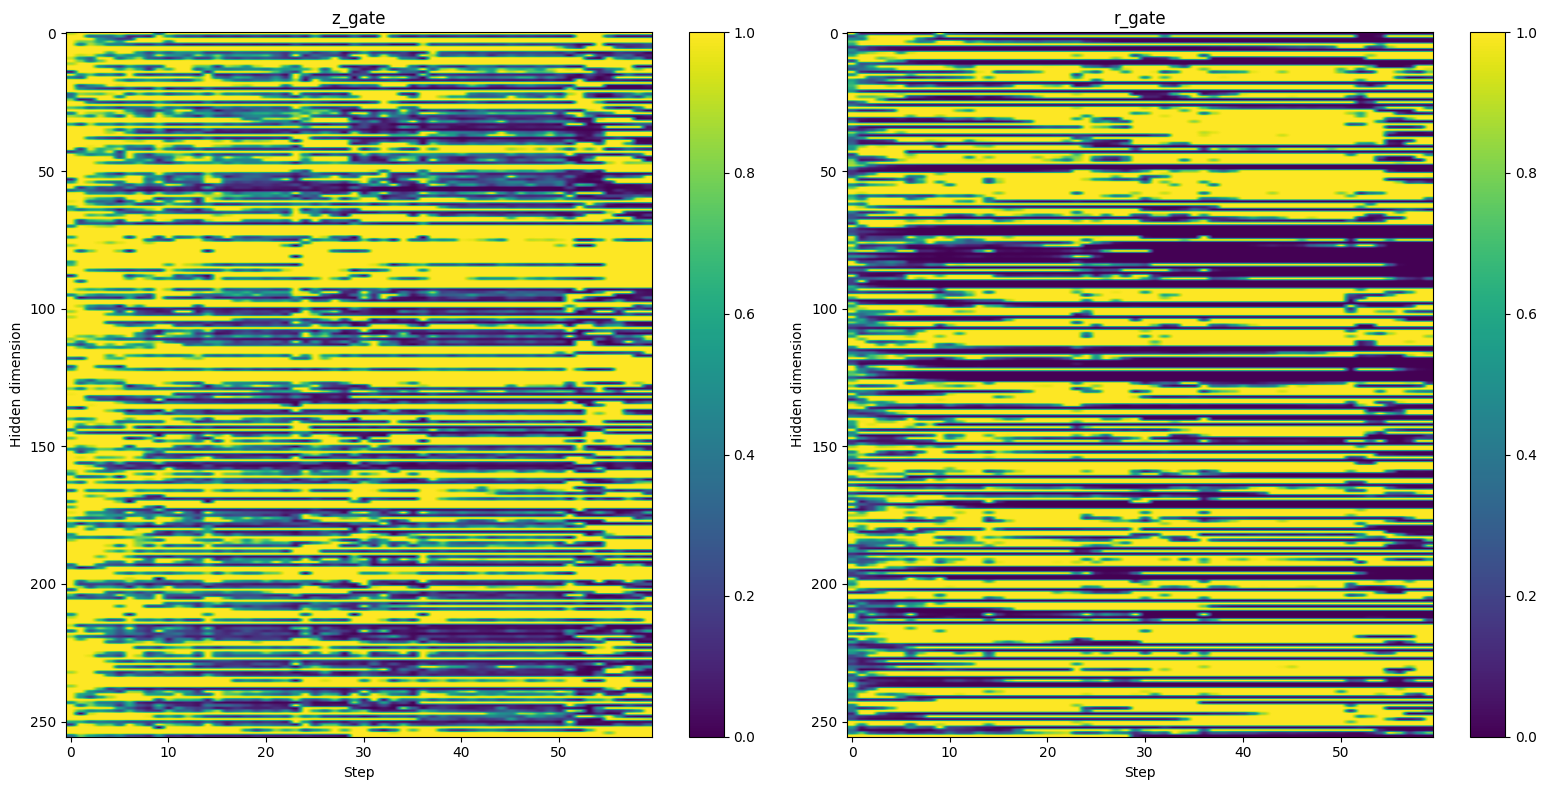

In [6]:
diagnose_ex3(eGRU_model, copy_size=10, buffer_size=50, vocab=vocab)

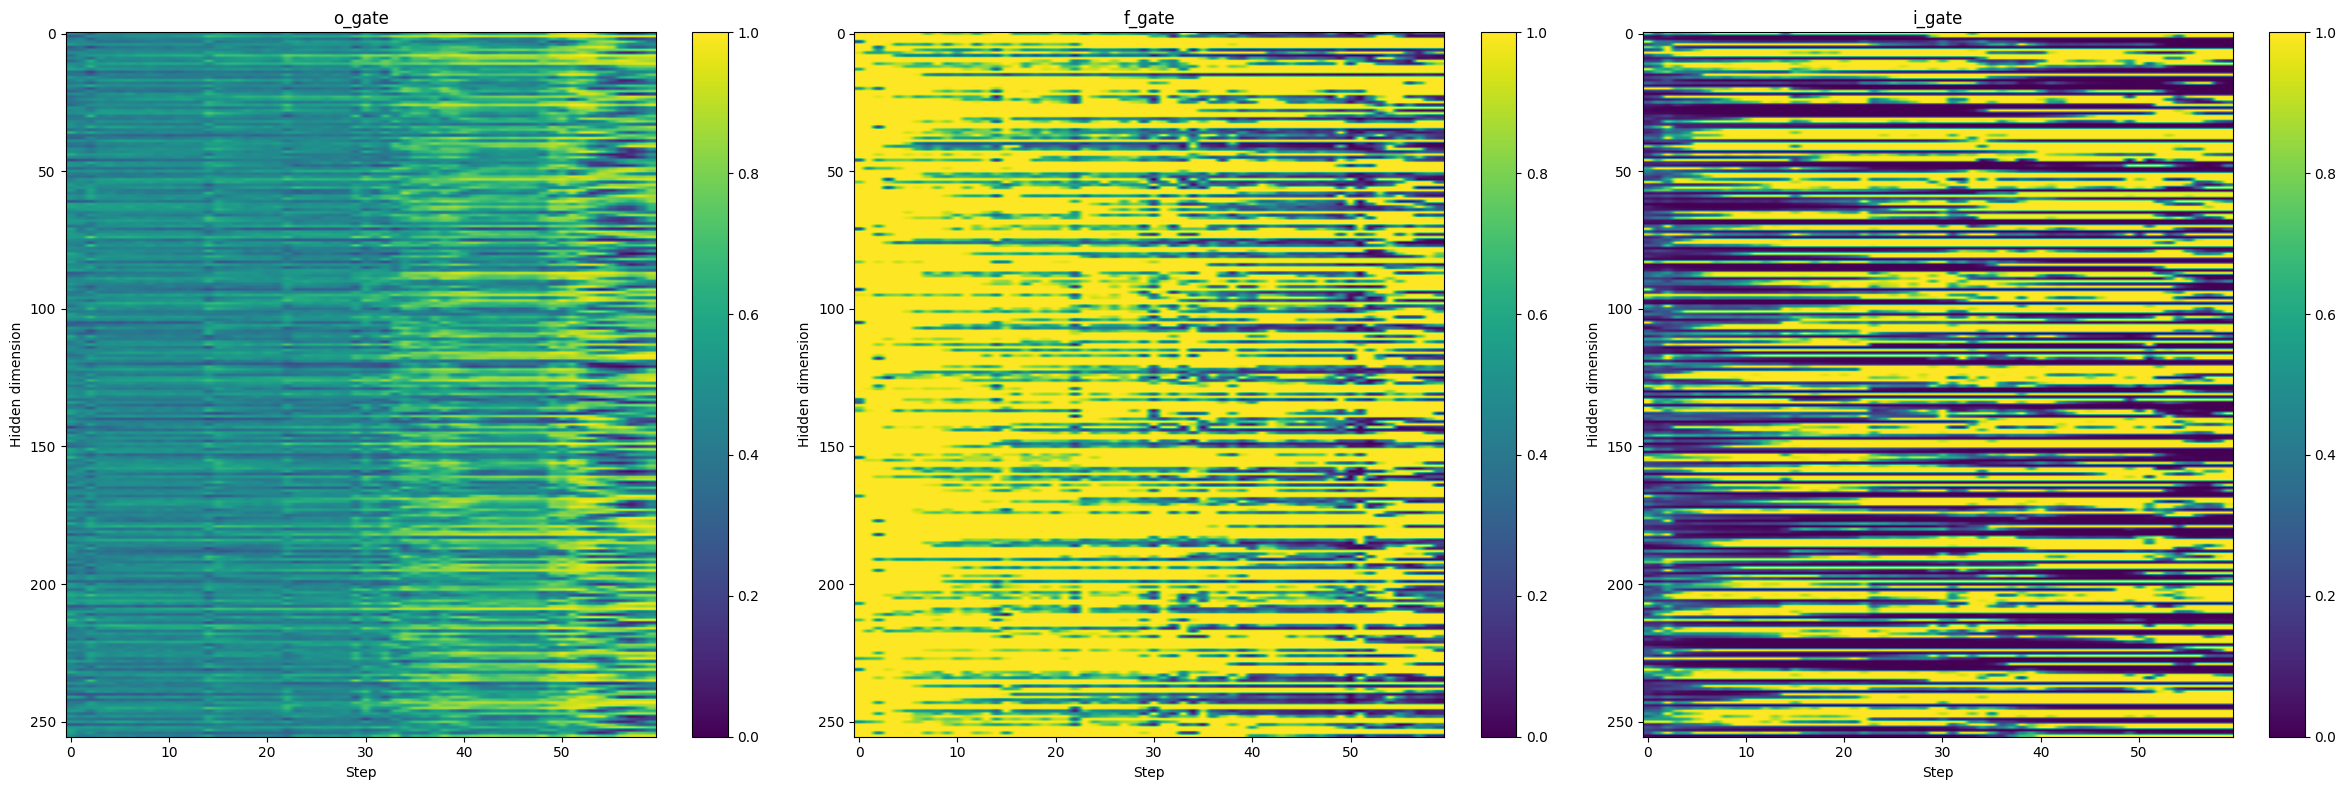

In [7]:
diagnose_ex3(sLSTM_model, copy_size=10, buffer_size=50, vocab=vocab)

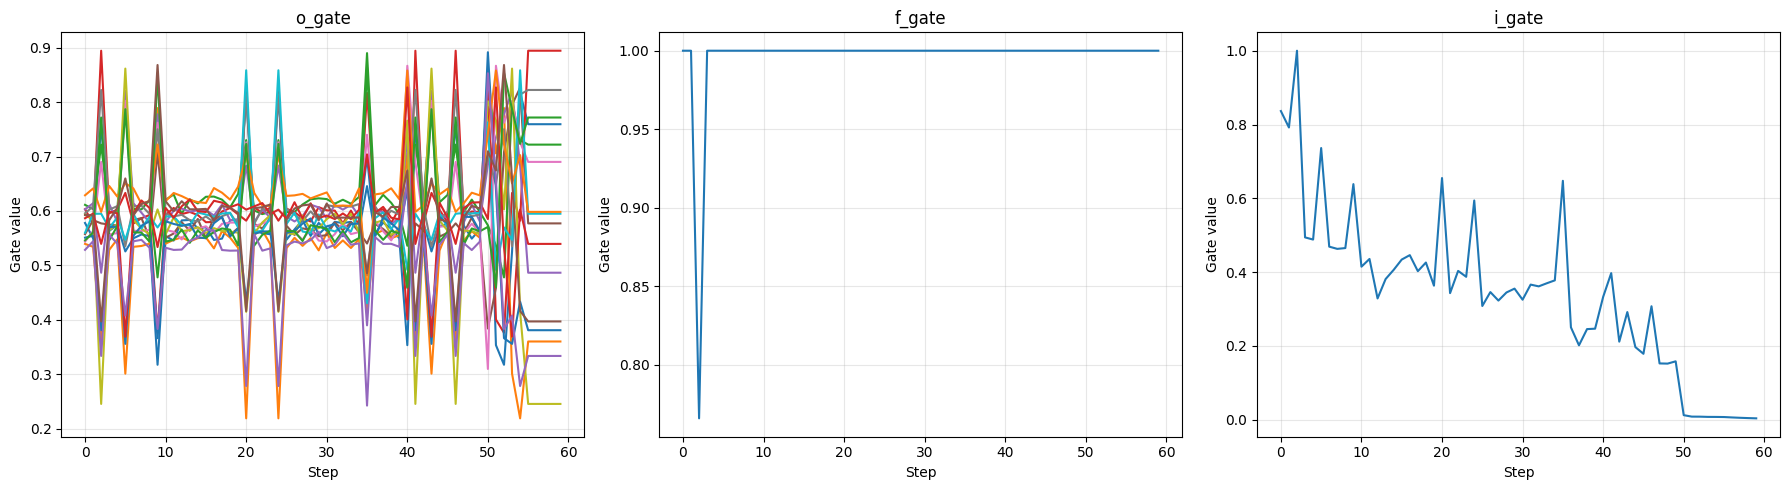

In [9]:
diagnose_ex3_scalar_graph(mLSTM_model, copy_size=10, buffer_size=50, vocab=vocab)

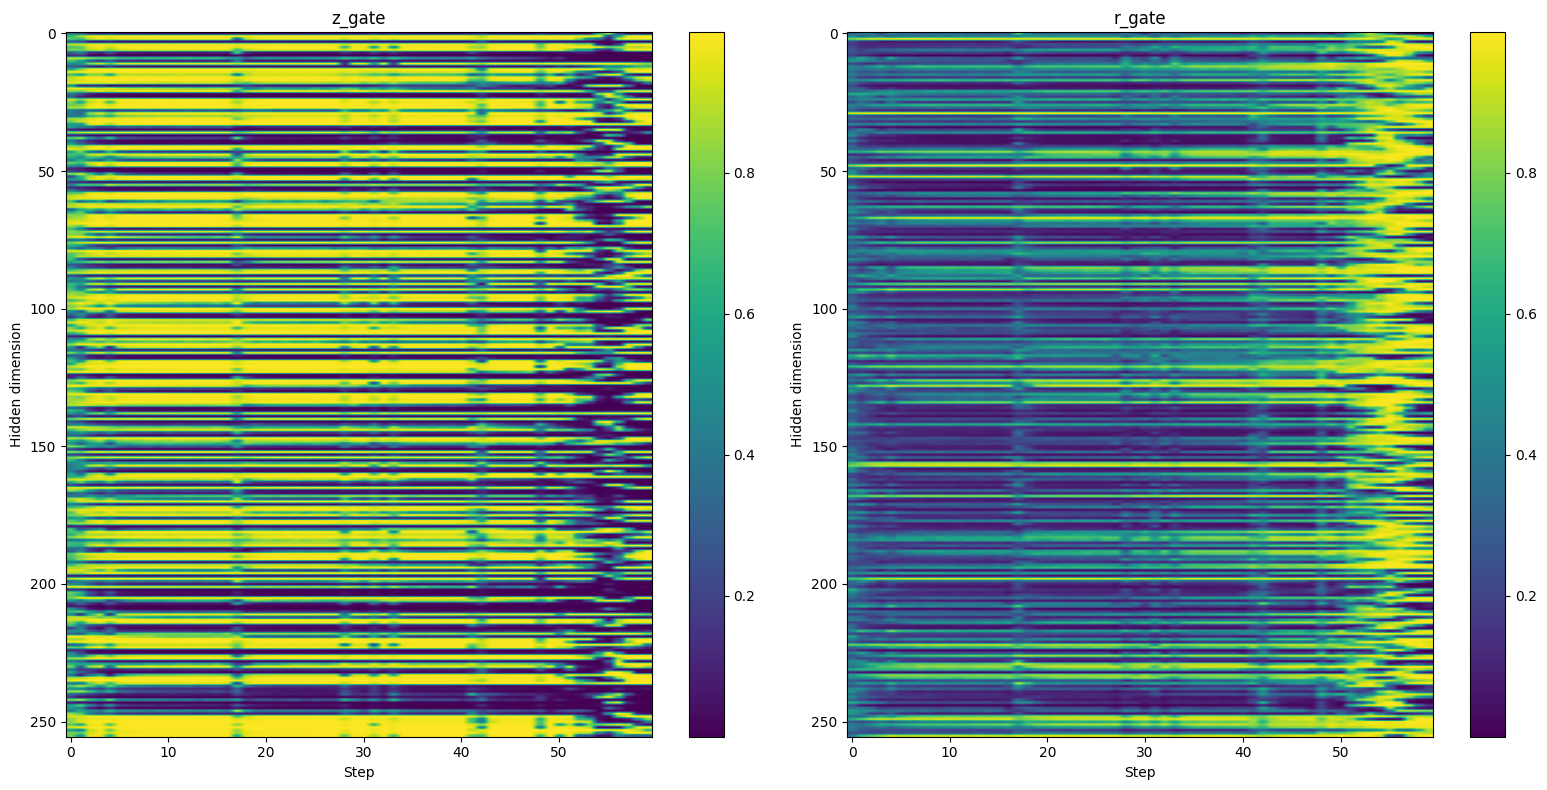

In [10]:
diagnose_ex3(GRU_model, copy_size=10, buffer_size=50, vocab=vocab)

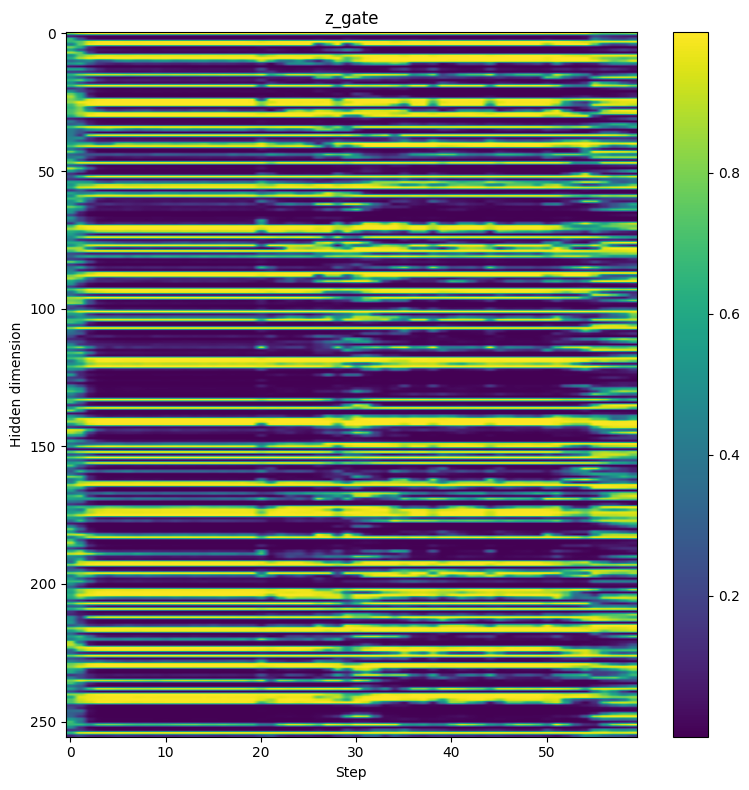

In [11]:
diagnose_ex3(MGU_model, copy_size=10, buffer_size=50, vocab=vocab)

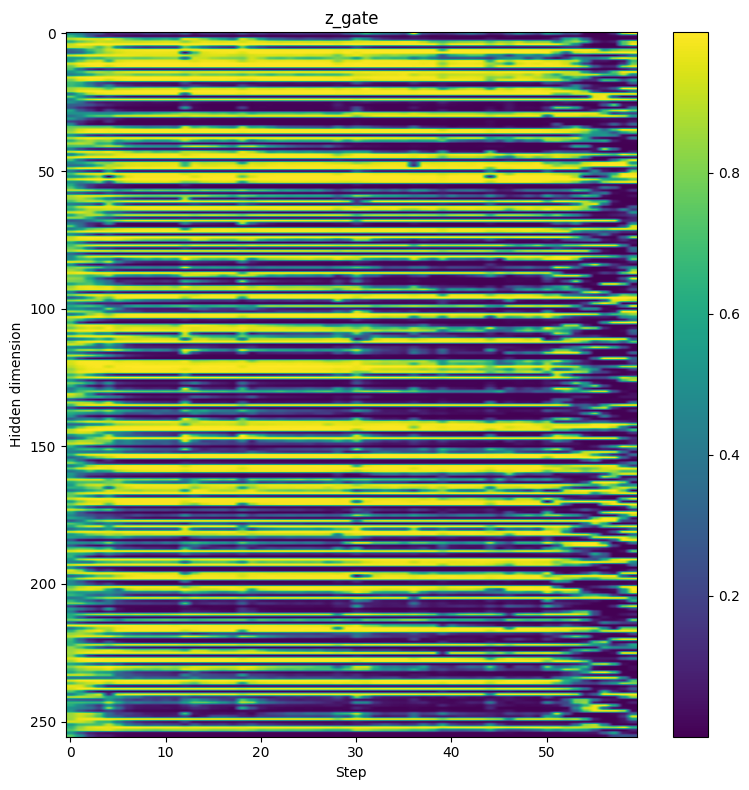

: 

In [ ]:
diagnose_ex3(maGRU_model, copy_size=10, buffer_size=50, vocab=vocab)

In [11]:

ex1_mlstm_50   =  evaluate_ex1(mLSTM_model,  copy_size=10, buffer_size=15, teacher_forcing=False,   total_batches=test_batches, batch_size=batch_size)
ex1_mlstm_100  =  evaluate_ex1(mLSTM_model,  copy_size=10, buffer_size=25, teacher_forcing=False,   total_batches=test_batches, batch_size=batch_size)
ex1_mlstm_250  =  evaluate_ex1(mLSTM_model,  copy_size=10, buffer_size=50, teacher_forcing=False,   total_batches=test_batches, batch_size=batch_size)
ex1_mlstm_500  =  evaluate_ex1(mLSTM_model,  copy_size=10, buffer_size=75, teacher_forcing=False,   total_batches=test_batches, batch_size=batch_size)
ex1_mlstm_750  =  evaluate_ex1(mLSTM_model, copy_size=10, buffer_size=100, teacher_forcing=False,  total_batches=test_batches, batch_size=batch_size)
ex1_mlstm_1000 = evaluate_ex1(mLSTM_model,  copy_size=10, buffer_size=250, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)

print("mLSTM bracket closing difference at buffer_size=50: ",   ex1_mlstm_50)
print("mLSTM bracket closing difference at buffer_size=100: ",  ex1_mlstm_100)
print("mLSTM bracket closing difference at buffer_size=250: ",  ex1_mlstm_250)
print("mLSTM bracket closing difference at buffer_size=500: ",  ex1_mlstm_500)
print("mLSTM bracket closing difference at buffer_size=750: ",  ex1_mlstm_750)
print("mLSTM bracket closing difference at buffer_size=1000: ", ex1_mlstm_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTM bracket closing difference at buffer_size=50:  0.7265470387912033
mLSTM bracket closing difference at buffer_size=100:  0.7338799621799205
mLSTM bracket closing difference at buffer_size=250:  0.7377165963154028
mLSTM bracket closing difference at buffer_size=500:  0.7379022405879332
mLSTM bracket closing difference at buffer_size=750:  0.7383972866700428
mLSTM bracket closing difference at buffer_size=1000:  0.7365408516166234


In [12]:

ex1_mlstmlite_50   = evaluate_ex1(mLSTMLite_model,  copy_size=10, buffer_size=15, teacher_forcing=False,  total_batches=test_batches, batch_size=batch_size)
ex1_mlstmlite_100  = evaluate_ex1(mLSTMLite_model,  copy_size=10, buffer_size=25, teacher_forcing=False,  total_batches=test_batches, batch_size=batch_size)
ex1_mlstmlite_250  = evaluate_ex1(mLSTMLite_model,  copy_size=10, buffer_size=50, teacher_forcing=False,  total_batches=test_batches, batch_size=batch_size)
ex1_mlstmlite_500  = evaluate_ex1(mLSTMLite_model,  copy_size=10, buffer_size=75, teacher_forcing=False,  total_batches=test_batches, batch_size=batch_size)
ex1_mlstmlite_750  = evaluate_ex1(mLSTMLite_model, copy_size=10, buffer_size=100, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_mlstmlite_1000 = evaluate_ex1(mLSTMLite_model, copy_size=10, buffer_size=250, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)

print("mLSTMLite bracket closing difference at buffer_size=50: ",   ex1_mlstmlite_50)
print("mLSTMLite bracket closing difference at buffer_size=100: ",  ex1_mlstmlite_100)
print("mLSTMLite bracket closing difference at buffer_size=250: ",  ex1_mlstmlite_250)
print("mLSTMLite bracket closing difference at buffer_size=500: ",  ex1_mlstmlite_500)
print("mLSTMLite bracket closing difference at buffer_size=750: ",  ex1_mlstmlite_750)
print("mLSTMLite bracket closing difference at buffer_size=1000: ", ex1_mlstmlite_1000)

Testing model at  15  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  25  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  50  buffer_size.


...

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTMLite bracket closing difference at buffer_size=50:  0.7359220420960153
mLSTMLite bracket closing difference at buffer_size=100:  0.7349010009576779
mLSTMLite bracket closing difference at buffer_size=250:  0.7380878836801736
mLSTMLite bracket closing difference at buffer_size=500:  0.7378712986955548
mLSTMLite bracket closing difference at buffer_size=750:  0.7425123883946108
mLSTMLite bracket closing difference at buffer_size=1000:  0.7398824373094162


In [13]:
ex1_cgru_50 =   evaluate_ex1(GRU_model, copy_size=10,   buffer_size=50, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_100 =  evaluate_ex1(GRU_model, copy_size=10,  buffer_size=100, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_250 =  evaluate_ex1(GRU_model, copy_size=10,  buffer_size=250, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_500 =  evaluate_ex1(GRU_model, copy_size=10,  buffer_size=500, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_750 =  evaluate_ex1(GRU_model, copy_size=10,  buffer_size=750, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_cgru_1000 = evaluate_ex1(GRU_model, copy_size=10, buffer_size=1000, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)

print("GRU synthetic copy difference at buffer_size=50: ", ex1_cgru_50)
print("GRU synthetic copy difference at buffer_size=100: ", ex1_cgru_100)
print("GRU synthetic copy difference at buffer_size=250: ", ex1_cgru_250)
print("GRU synthetic copy difference at buffer_size=500: ", ex1_cgru_500)
print("GRU synthetic copy difference at buffer_size=750: ", ex1_cgru_750)
print("GRU synthetic copy difference at buffer_size=1000: ", ex1_cgru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

GRU synthetic copy difference at buffer_size=50:  0.15584777568531508
GRU synthetic copy difference at buffer_size=100:  0.0736076748459646
GRU synthetic copy difference at buffer_size=250:  0.19161510246224922
GRU synthetic copy difference at buffer_size=500:  0.37688738255217524
GRU synthetic copy difference at buffer_size=750:  0.45816832456258266
GRU synthetic copy difference at buffer_size=1000:  0.5076732791886471


In [14]:
ex1_mgu_50 =   evaluate_ex1(MGU_model, copy_size=10,   buffer_size=50, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_100 =  evaluate_ex1(MGU_model, copy_size=10,  buffer_size=100, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_250 =  evaluate_ex1(MGU_model, copy_size=10,  buffer_size=250, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_500 =  evaluate_ex1(MGU_model, copy_size=10,  buffer_size=500, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_750 =  evaluate_ex1(MGU_model, copy_size=10,  buffer_size=750, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_mgu_1000 = evaluate_ex1(MGU_model, copy_size=10, buffer_size=1000, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)

print("MGU synthetic copy difference at buffer_size=50: ",   ex1_mgu_50)
print("MGU synthetic copy difference at buffer_size=100: ",  ex1_mgu_100)
print("MGU synthetic copy difference at buffer_size=250: ",  ex1_mgu_250)
print("MGU synthetic copy difference at buffer_size=500: ",  ex1_mgu_500)
print("MGU synthetic copy difference at buffer_size=750: ",  ex1_mgu_750)
print("MGU synthetic copy difference at buffer_size=1000: ", ex1_mgu_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

MGU synthetic copy difference at buffer_size=50:  0.5891398625208599
MGU synthetic copy difference at buffer_size=100:  0.37017327399537114
MGU synthetic copy difference at buffer_size=250:  0.5210086738709176
MGU synthetic copy difference at buffer_size=500:  0.6386448139011269
MGU synthetic copy difference at buffer_size=750:  0.6772586738709176
MGU synthetic copy difference at buffer_size=1000:  0.701299517461569


In [15]:
ex1_slstm_50 =   evaluate_ex1(sLSTM_model, copy_size=10,   buffer_size=50, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_100 =  evaluate_ex1(sLSTM_model, copy_size=10,  buffer_size=100, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_250 =  evaluate_ex1(sLSTM_model, copy_size=10,  buffer_size=250, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_500 =  evaluate_ex1(sLSTM_model, copy_size=10,  buffer_size=500, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_750 =  evaluate_ex1(sLSTM_model, copy_size=10,  buffer_size=750, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)
ex1_slstm_1000 = evaluate_ex1(sLSTM_model, copy_size=10, buffer_size=1000, teacher_forcing=False, total_batches=test_batches, batch_size=batch_size)

print("sLSTM synthetic copy difference at buffer_size=50: ",   ex1_slstm_50)
print("sLSTM synthetic copy difference at buffer_size=100: ",  ex1_slstm_100)
print("sLSTM synthetic copy difference at buffer_size=250: ",  ex1_slstm_250)
print("sLSTM synthetic copy difference at buffer_size=500: ",  ex1_slstm_500)
print("sLSTM synthetic copy difference at buffer_size=750: ",  ex1_slstm_750)
print("sLSTM synthetic copy difference at buffer_size=1000: ", ex1_slstm_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

sLSTM synthetic copy difference at buffer_size=50:  0.040563119619181104
sLSTM synthetic copy difference at buffer_size=100:  0.043440595158551
sLSTM synthetic copy difference at buffer_size=250:  0.037561881886149694
sLSTM synthetic copy difference at buffer_size=500:  0.0426670798644571
sLSTM synthetic copy difference at buffer_size=750:  0.04362623832917007
sLSTM synthetic copy difference at buffer_size=1000:  0.04325495125486119


In [8]:
ex1_magru_50 =   evaluate_ex1(maGRU_model, copy_size=10, teacher_forcing=False, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_magru_100 =  evaluate_ex1(maGRU_model, copy_size=10, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_magru_250 =  evaluate_ex1(maGRU_model, copy_size=10, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_magru_500 =  evaluate_ex1(maGRU_model, copy_size=10, teacher_forcing=False, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_magru_750 =  evaluate_ex1(maGRU_model, copy_size=10, teacher_forcing=False, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_magru_1000 = evaluate_ex1(maGRU_model, copy_size=10, teacher_forcing=False, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("maGRU synthetic copy difference at buffer_size=50: ",   ex1_magru_50)
print("maGRU synthetic copy difference at buffer_size=100: ",  ex1_magru_100)
print("maGRU synthetic copy difference at buffer_size=250: ",  ex1_magru_250)
print("maGRU synthetic copy difference at buffer_size=500: ",  ex1_magru_500)
print("maGRU synthetic copy difference at buffer_size=750: ",  ex1_magru_750)
print("maGRU synthetic copy difference at buffer_size=1000: ", ex1_magru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

maGRU synthetic copy difference at buffer_size=50:  0.12852722981778703
maGRU synthetic copy difference at buffer_size=100:  0.05788985229014318
maGRU synthetic copy difference at buffer_size=250:  0.1709777263574081
maGRU synthetic copy difference at buffer_size=500:  0.31472772890978523
maGRU synthetic copy difference at buffer_size=750:  0.3720915904729673
maGRU synthetic copy difference at buffer_size=1000:  0.4048267372763983


In [7]:
ex1_eGRU_50 =   evaluate_ex1(eGRU_model, copy_size=10, teacher_forcing=False, buffer_size=50, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_100 =  evaluate_ex1(eGRU_model, copy_size=10, teacher_forcing=False, buffer_size=100, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_250 =  evaluate_ex1(eGRU_model, copy_size=10, teacher_forcing=False, buffer_size=250, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_500 =  evaluate_ex1(eGRU_model, copy_size=10, teacher_forcing=False, buffer_size=500, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_750 =  evaluate_ex1(eGRU_model, copy_size=10, teacher_forcing=False, buffer_size=750, total_batches=test_batches, batch_size=batch_size)
ex1_eGRU_1000 = evaluate_ex1(eGRU_model, copy_size=10, teacher_forcing=False, buffer_size=1000, total_batches=test_batches, batch_size=batch_size)

print("eGRU synthetic copy difference at buffer_size=50: ",   ex1_eGRU_50)
print("eGRU synthetic copy difference at buffer_size=100: ",  ex1_eGRU_100)
print("eGRU synthetic copy difference at buffer_size=250: ",  ex1_eGRU_250)
print("eGRU synthetic copy difference at buffer_size=500: ",  ex1_eGRU_500)
print("eGRU synthetic copy difference at buffer_size=750: ",  ex1_eGRU_750)
print("eGRU synthetic copy difference at buffer_size=1000: ", ex1_eGRU_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU synthetic copy difference at buffer_size=50:  0.024040841887068776
eGRU synthetic copy difference at buffer_size=100:  0.022834158765318077
eGRU synthetic copy difference at buffer_size=250:  0.024257426124785354
eGRU synthetic copy difference at buffer_size=500:  0.02478341627312769
eGRU synthetic copy difference at buffer_size=750:  0.021410891557997552
eGRU synthetic copy difference at buffer_size=1000:  0.02394802034786432


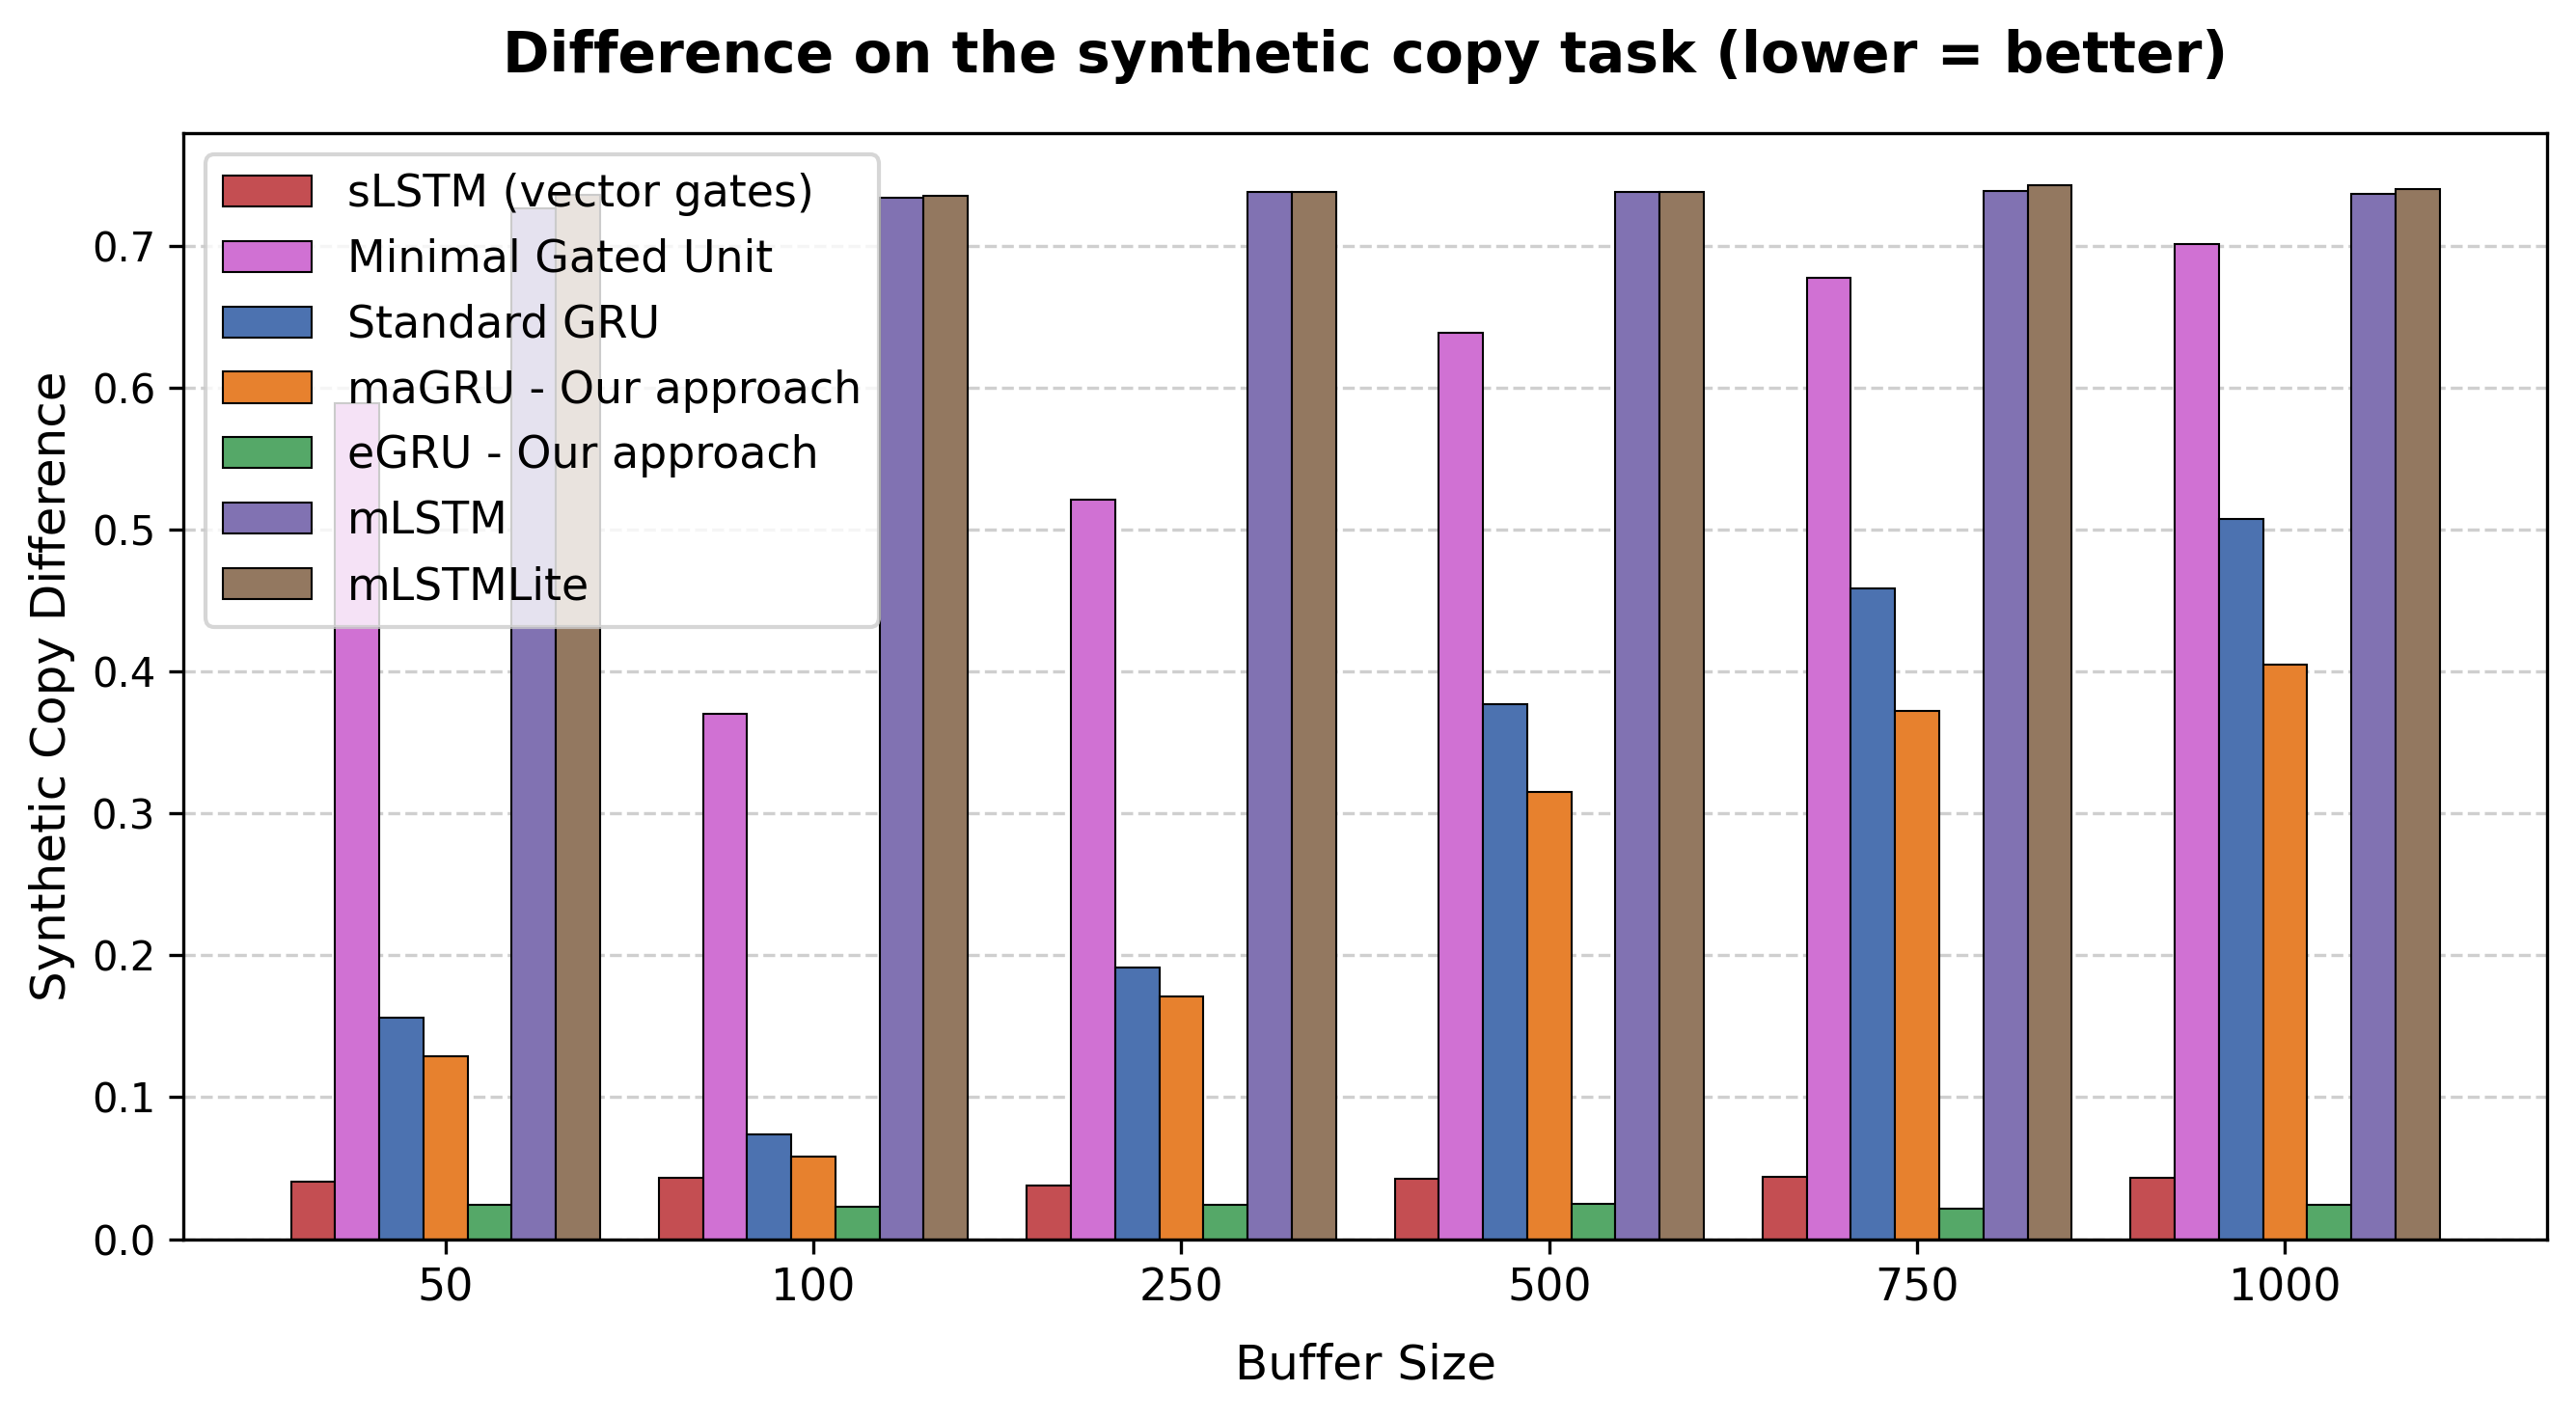

In [9]:
standard_gru = [
    0.15584777568531508,
     0.0736076748459646,
     0.19161510246224922,
     0.37688738255217524,
     0.45816832456258266,
      0.5076732791886471
]

egru = [
   0.024040841887068776,
    0.022834158765318077,
    0.024257426124785354,
    0.02478341627312769,
    0.021410891557997552,
     0.02394802034786432
]

magru = [
    0.12852722981778703,
     0.05788985229014318,
     0.1709777263574081,
     0.31472772890978523,
     0.3720915904729673,
      0.4048267372763983
]

MGU = [
    0.5891398625208599,
     0.37017327399537114,
     0.5210086738709176,
     0.6386448139011269,
     0.6772586738709176,
      0.701299517461569
]

sLSTM = [
    0.040563119619181104,
     0.043440595158551,
     0.037561881886149694,
     0.0426670798644571,
     0.04362623832917007,
      0.04325495125486119
]

mLSTM = [
    0.7265470387912033,
     0.7338799621799205,
     0.7377165963154028,
     0.7379022405879332,
     0.7383972866700428,
      0.7365408516166234
]
mLSTMLite = [
 0.7359220420960153,
  0.7349010009576779,
  0.7380878836801736,
  0.7378712986955548,
  0.7425123883946108,
   0.7398824373094162
]


import matplotlib.pyplot as plt
import numpy as np

# Data

buffer_sizes = ["50", "100", "250", "500", "750", "1000"]



# Plot setup

x = np.arange(len(buffer_sizes))
width = 0.12

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# Create bars
rects0 = ax.bar(
    x - 3 * width,
    sLSTM,
    width,
    label="sLSTM (vector gates)",
    color="#C44E52",
    edgecolor="black",
    linewidth=0.5,
)

rects1 = ax.bar(
    x - 2 * width,
    MGU,
    width,
    label="Minimal Gated Unit",
    color="#D071D3",
    edgecolor="black",
    linewidth=0.5,
)

rects2 = ax.bar(
    x - width,
    standard_gru,
    width,
    label="Standard GRU",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

rects3 = ax.bar(
    x,
    magru,
    width,
    label="maGRU - Our approach",
    color="#E7812E",
    edgecolor="black",
    linewidth=0.5,
)

rects4 = ax.bar(
    x + width,
    egru,
    width,
    label="eGRU - Our approach",
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

rects5 = ax.bar(
    x + 2 * width,
    mLSTM,
    width,
    label="mLSTM",
    color="#8172B2",
    edgecolor="black",
    linewidth=0.5,
)

rects6 = ax.bar(
    x + 3 * width,
    mLSTMLite,
    width,
    label="mLSTMLite",
    color="#937860",
    edgecolor="black",
    linewidth=0.5,
)


# Titles and labels

ax.set_title(
    "Difference on the synthetic copy task (lower = better)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel(
    "Buffer Size",
    fontsize=12,
    fontweight="medium",
    labelpad=8,
)

ax.set_ylabel(
    "Synthetic Copy Difference",
    fontsize=12,
    fontweight="medium",
)

ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=11)


# Aesthetics

ax.legend(fontsize=11, frameon=True)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.6,
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()